In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
arquivo = r"c:\Users\Halina\Portfólio\PostgreSQL\Ecommerce Novo\Ecommerce Novo.xlsx"  

df = pd.read_excel(arquivo, sheet_name="RECEITA REAL POR VENDA")

print("Dados carregados com sucesso")
df.head()

Dados carregados com sucesso


,Venda Id,Data Venda,Cliente Id,Canal Id,Canal,Receita Real
0,112,2026-01-22 00:28:41.357672,23,1,Marketplace,14510.06
1,391,2026-01-14 14:30:33.546818,163,1,Marketplace,8271.64
2,199,2025-12-31 16:46:04.12168,44,3,Loja Fisica,8138.96
3,318,2025-09-04 05:47:26.585667,187,1,Marketplace,10940.40
4,62,2025-10-22 06:21:51.260894,26,1,Marketplace,11940.04


In [6]:
df = df.loc[:, ~df.columns.str.contains("Unnamed")]

df = df.rename(columns={
    "Venda Id": "venda_id",
    "Data Venda": "data_venda",
    "Cliente Id": "cliente_id",
    "Canal Id": "canal_id",
    "Canal": "canal",
    "Receita Real": "receita_real"
})

df.head()

,venda_id,data_venda,cliente_id,canal_id,canal,receita_real
0,112,2026-01-22 00:28:41.357672,23,1,Marketplace,14510.06
1,391,2026-01-14 14:30:33.546818,163,1,Marketplace,8271.64
2,199,2025-12-31 16:46:04.12168,44,3,Loja Fisica,8138.96
3,318,2025-09-04 05:47:26.585667,187,1,Marketplace,10940.40
4,62,2025-10-22 06:21:51.260894,26,1,Marketplace,11940.04


In [7]:
df["data_venda"] = pd.to_datetime(df["data_venda"])

df["mes"] = df["data_venda"].dt.to_period("M")

df.head()

,venda_id,data_venda,cliente_id,canal_id,canal,receita_real,mes
0,112,2026-01-22 00:28:41.357672,23,1,Marketplace,14510.06,2026-01
1,391,2026-01-14 14:30:33.546818,163,1,Marketplace,8271.64,2026-01
2,199,2025-12-31 16:46:04.121680,44,3,Loja Fisica,8138.96,2025-12
3,318,2025-09-04 05:47:26.585667,187,1,Marketplace,10940.40,2025-09
4,62,2025-10-22 06:21:51.260894,26,1,Marketplace,11940.04,2025-10


In [8]:
faturamento_total = df["receita_real"].sum()

ticket_medio = df["receita_real"].mean()

vendas_mes = df.groupby("mes")["receita_real"].sum()

vendas_canal = df.groupby("canal")["receita_real"].sum()

print("Faturamento total:", faturamento_total)
print("Ticket médio:", ticket_medio)

print("\nFaturamento por canal")
print(vendas_canal)

Faturamento total: 3691820.42
Ticket médio: 10954.956735905043

Faturamento por canal
canal
Loja Fisica     184854.48
Marketplace    1887647.98
Site           1619317.96
Name: receita_real, dtype: float64


In [9]:
crescimento = vendas_mes.pct_change() * 100

crescimento

mes
2025-08          NaN
2025-09    64.784945
2025-10   -39.879564
2025-11    46.635094
2025-12    -1.312365
2026-01    12.800368
2026-02   -35.105065
2026-03   -85.676661
Freq: M, Name: receita_real, dtype: float64

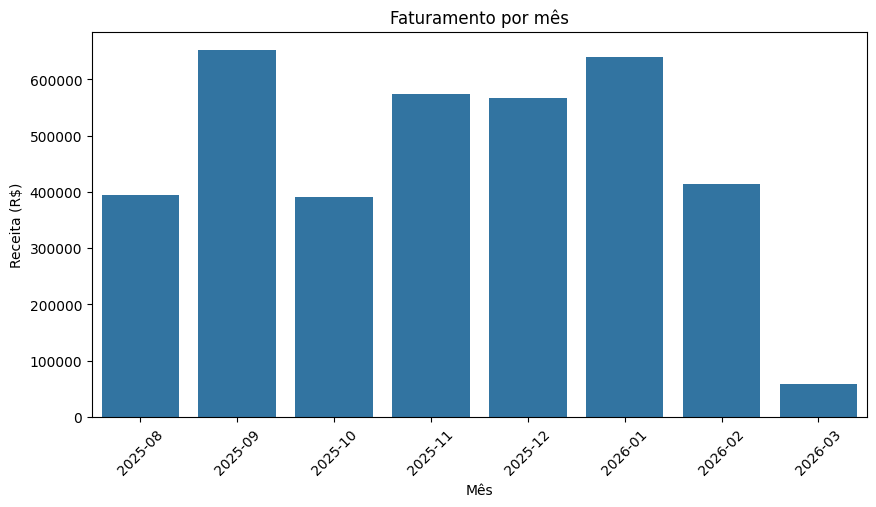

In [10]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=vendas_mes.index.astype(str),
    y=vendas_mes.values
)

plt.title("Faturamento por mês")
plt.ylabel("Receita (R$)")
plt.xlabel("Mês")

plt.xticks(rotation=45)

plt.show()

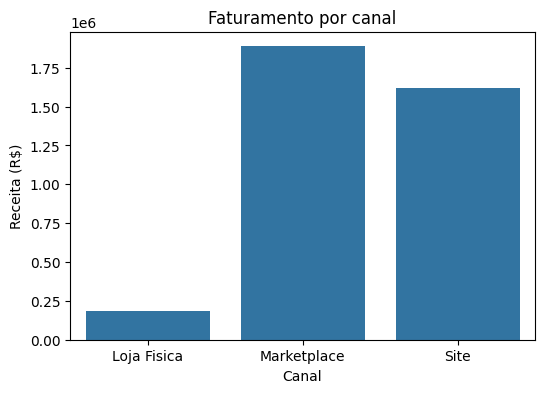

In [11]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=vendas_canal.index,
    y=vendas_canal.values
)

plt.title("Faturamento por canal")
plt.ylabel("Receita (R$)")
plt.xlabel("Canal")

plt.show()

In [12]:
print("INSIGHTS DE NEGÓCIO\n")

canal_top = vendas_canal.idxmax()
valor_top = vendas_canal.max()

print(f"Canal com maior faturamento: {canal_top}")

mes_top = vendas_mes.idxmax()

print(f"Mês com maior faturamento: {mes_top}")

print(f"Ticket médio geral: {ticket_medio:,.2f}")

INSIGHTS DE NEGÓCIO

Canal com maior faturamento: Marketplace
Mês com maior faturamento: 2025-09
Ticket médio geral: 10,954.96
